In [1]:
import numpy as np
import random
from math import exp,log
import matplotlib.pyplot as plt

In [2]:
# Data prepration
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
Y = np.array([0, 1, 1, 0])

In [3]:
# Model
class logistic_regression_model():
    def __init__(self):
        self.w = [random.random(), random.random()]
        self.b = random.random()
        
    def sigmoid(self, z):
        return 1/(1 + exp(-z))
    
    def predict(self, x):
        z = np.inner(self.w, x) + self.b
        a = self.sigmoid(z)
        return a

In [4]:
XOR_model1 = logistic_regression_model()
XOR_model2 = logistic_regression_model()
XOR_model3 = logistic_regression_model()

In [5]:
# Training
def train(X, Y, model, lr):
    dw0 = 0.0
    dw1 = 0.0
    db = 0.0
    m = len(X)
    cost = 0.0
    
    for x, y in zip(X, Y):
        a = model.predict(x)
        if y == 1:
            cost -= log(a)
        else:
            cost -= log(1-a)
            
        dw0 += (a-y)*x[0]
        dw1 += (a-y)*x[1]
        db += (a-y)
            
    cost /= m
    model.w[0] -= lr * dw0/m
    model.w[1] -= lr * dw1/m
    model.b -= lr * db/m
        
    return cost

In [6]:
XOR_loss1 = []
XOR_loss2 = []
XOR_loss3 = []

for epoch in range(10000):
        # learning rate 0.01
        XOR_loss1.append(train(X, Y, XOR_model1, 0.01))
        # learning rate 0.1
        XOR_loss2.append(train(X, Y, XOR_model2, 0.1))
        # learning rate 0.5
        XOR_loss3.append(train(X, Y, XOR_model3, 0.5))

epoch = [x for x in range(10000)]

XOR_loss1 = np.array(XOR_loss1)
XOR_loss2 = np.array(XOR_loss2)
XOR_loss3 = np.array(XOR_loss3)

In [7]:
# learning rate = 0.01
print(XOR_model1.predict((0,0)))
print(XOR_model1.predict((0,1)))
print(XOR_model1.predict((1,0)))
print(XOR_model1.predict((1,1)))

0.49736195367652103
0.49959315973403423
0.49957885448440587
0.5018100769241222


In [8]:
# learning rate = 0.1
print(XOR_model2.predict((0,0)))
print(XOR_model2.predict((0,1)))
print(XOR_model2.predict((1,0)))
print(XOR_model2.predict((1,1)))

0.5
0.5
0.5
0.5


In [9]:
# learning rate = 0.5
print(XOR_model3.predict((0,0)))
print(XOR_model3.predict((0,1)))
print(XOR_model3.predict((1,0)))
print(XOR_model3.predict((1,1)))

0.5
0.5
0.5
0.5


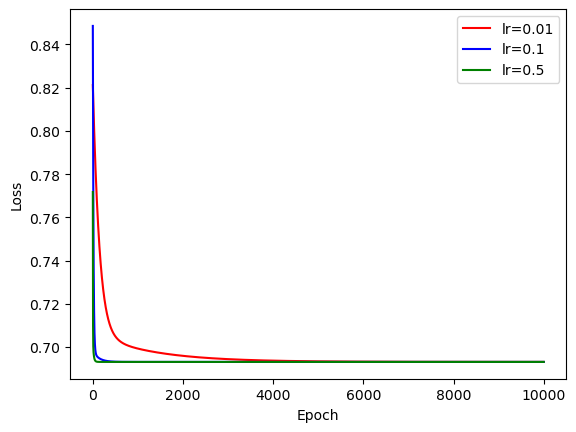

In [10]:
# loss plot
plt.plot(epoch, XOR_loss1, 'r-', label = 'lr=0.01')
plt.plot(epoch, XOR_loss2, 'b-', label = 'lr=0.1')
plt.plot(epoch, XOR_loss3, 'g-', label = 'lr=0.5')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()